In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [9]:
core_path = os.getcwd()
results_path = os.path.join(core_path, 'data/results')
plots_path   = os.path.join(core_path, 'plots')
os.makedirs(results_path, exist_ok=True)
os.makedirs(plots_path,   exist_ok=True)
asteroids_df   = pd.read_pickle(os.path.join(core_path, 'data/lvl2/asteroids.pkl'))
orbital_df     = pd.read_pickle(os.path.join(core_path, 'data/lvl2/orbital_df.pkl'))

In [ ]:
#Extract Numeric ID from Asteroid Name String
# '433 Eros'    → '433'
# '1995 BM2'    → None

def extract_asteroid_number(name):
    if pd.isna(name):
        return None

    name = str(name).strip()

    # Format: starts with a number (numbered asteroid)
    match = re.match(r'^(\d+)', name)
    if match:
        return match.group(1)

    # Provisional designation only — no permanent number
    return None

# Apply to SMASS II
asteroids_df['Asteroid_id'] = asteroids_df['Name'].apply(extract_asteroid_number)

# Check extraction results
n_numbered     = asteroids_df['Asteroid_id'].notna().sum()
n_provisional  = asteroids_df['Asteroid_id'].isna().sum()

print(f"Numbered asteroids (can match) : {n_numbered:,}")
print(f"Provisional designations only  : {n_provisional:,}")
print(f"\nSample extracted IDs:")
print(asteroids_df[['Name', 'Asteroid_id']].head(20).to_string())

Numbered asteroids (can match) : 1,339
Provisional designations only  : 0

Sample extracted IDs:
             Name Asteroid_id
0         1 Ceres           1
1        2 Pallas           2
2          3 Juno           3
3         4 Vesta           4
4       5 Astraea           5
5          6 Hebe           6
6          7 Iris           7
7       10 Hygiea          10
8   11 Parthenope          11
9     12 Victoria          12
10      13 Egeria          13
11       14 Irene          14
12     15 Eunomia          15
13      16 Psyche          16
14      17 Thetis          17
15   18 Melpomene          18
16     19 Fortuna          19
17    20 Massalia          20
18     21 Lutetia          21
19    22 Kalliope          22


In [11]:
# Ensure same dtype for merge
asteroids_df['Asteroid_id'] = asteroids_df['Asteroid_id'].astype(str)
orbital_df['Asteroid_id']   = orbital_df['Asteroid_id'].astype(str)

# Keep only numbered SMASS II asteroids
smass_numbered = asteroids_df[asteroids_df['Asteroid_id'].notna()].copy()

# Merge
matched_df = smass_numbered.merge(
    orbital_df,
    on='Asteroid_id',
    how='inner'
)

# Unmatched SMASS II asteroids
unmatched_smass = smass_numbered[
    ~smass_numbered['Asteroid_id'].isin(orbital_df['Asteroid_id'])
]

print(f"SMASS II total              : {len(asteroids_df):,}")
print(f"SMASS II numbered           : {len(smass_numbered):,}")
print(f"Successfully matched        : {len(matched_df):,}")
print(f"Unmatched (not in orbital)  : {len(unmatched_smass):,}")
print(f"Provisional (no number)     : {n_provisional:,}")
print(f"\nMatch rate                  : {100*len(matched_df)/len(smass_numbered):.1f}%")

SMASS II total              : 1,339
SMASS II numbered           : 1,339
Successfully matched        : 1,181
Unmatched (not in orbital)  : 158
Provisional (no number)     : 0

Match rate                  : 88.2%


In [12]:
print("=== Taxonomy Distribution in Matched Dataset ===\n")

print("Bus Class (detailed):")
print(matched_df['Bus Class'].value_counts().to_string())

print("\nMain Group (4-class):")
print(matched_df['Main Group'].value_counts().to_string())

print(f"\nClass balance:")
for group, count in matched_df['Main Group'].value_counts().items():
    print(f"  {group:<10} : {count:>4}  ({100*count/len(matched_df):.1f}%)")

=== Taxonomy Distribution in Matched Dataset ===

Bus Class (detailed):
Bus Class
S      339
C      132
Ch     132
X       90
Xc      53
Sq      49
B       45
Sl      43
V       35
Xk      34
L       32
K       31
Sa      31
Cb      27
Xe      19
Cgh     14
Sk      13
Sr      13
Ld      12
A       10
T       10
Cg       7
D        5
R        4
O        1

Main Group (4-class):
Main Group
S        488
C        357
X        196
Other    140

Class balance:
  S          :  488  (41.3%)
  C          :  357  (30.2%)
  X          :  196  (16.6%)
  Other      :  140  (11.9%)


In [13]:
# Extract only unmatched asteroid names
unmatched_names = unmatched_smass['Name']

print(unmatched_names.to_string(index=False))

          2 Pallas
         5 Astraea
     29 Amphitrite
         32 Pomona
         65 Cybele
          76 Freia
         87 Sylvia
         91 Aegina
         92 Undina
         106 Dione
       107 Camilla
        108 Hecuba
      121 Hermione
         122 Gerda
    125 Liberatrix
        132 Aethra
         153 Hilda
           164 Eva
       168 Sibylla
       174 Phaedra
    175 Andromache
      184 Dejopeja
       188 Menippe
        190 Ismene
         191 Kolga
     196 Philomela
         279 Thule
     355 Gabriella
        381 Myrrha
       413 Edburga
       414 Liriope
      434 Hungaria
         470 Kilia
       507 Laodica
       531 Zerlina
     545 Messalina
        551 Ortrud
         555 Norma
       563 Suleika
       570 Kythera
         642 Clara
          699 Hela
    704 Interamnia
      713 Luscinia
         731 Sorga
      759 Vinifera
     781 Kartvelia
      844 Leontina
     898 Hildegard
       970 Primula
        973 Aralia
     1011 Laodamia
      1015 C

In [ ]:
# How many matched asteroids are family members
fam_matched = matched_df[matched_df['is_family_member']]    # Family members
bg_matched  = matched_df[~matched_df['is_family_member']]   # Background members

print(f"Matched family members : {len(fam_matched):,}")
print(f"Matched background     : {len(bg_matched):,}")

# Which families have SMASS II coverage
family_coverage = (
    fam_matched.groupby('family_1')
    .agg(
        n_members       = ('Asteroid_id', 'count'),
        taxonomy_counts = ('Main Group', lambda x: dict(x.value_counts()))
    )
    .sort_values('n_members', ascending=False)
)

print(f"\nFamilies with SMASS II coverage : {len(family_coverage)}")
print(f"Families with 5+ members        : {(family_coverage['n_members'] >= 5).sum()}")
print(f"Families with 10+ members       : {(family_coverage['n_members'] >= 10).sum()}")

print(f"\nTop 15 families by SMASS II coverage:")
print(family_coverage.head(15).to_string())

Matched family members : 275
Matched background     : 906

Families with SMASS II coverage : 42
Families with 5+ members        : 17
Families with 10+ members       : 10

Top 15 families by SMASS II coverage:
          n_members                        taxonomy_counts
family_1                                                  
93               35                      {'S': 34, 'C': 1}
668              28                              {'C': 28}
158              22                              {'S': 22}
847              22                  {'S': 15, 'Other': 7}
221              21  {'Other': 15, 'X': 3, 'S': 2, 'C': 1}
4                19                  {'Other': 13, 'S': 6}
24               15                              {'C': 15}
15               14              {'S': 11, 'X': 2, 'C': 1}
1726             10               {'C': 8, 'X': 1, 'S': 1}
110              10                       {'X': 8, 'C': 2}
808               8                       {'S': 7, 'X': 1}
145               8     

In [ ]:
# Extract wavelengths from the first spectrum (all spectra share the same wavelength grid)

wavelengths = matched_df['SpectrumDF'].iloc[0]['Wavelength_in_micron'].values

# Key wavelength indices
IDX = {
    'vis_start'  : 0,       # 0.44 μm
    'norm'       : 11,      # 0.55 μm — normalization point
    'vis_end'    : 26,      # 0.70 μm
    'hydration'  : 33,      # 0.73 μm — 0.7 μm band region
    'nir_start'  : 26,      # 0.70 μm
    'nir_end'    : 48,      # 0.92 μm — onset of 1 μm band
}

# Extract spectral features for each asteroid
def extract_spectral_features(spectrum_df):
    wav = spectrum_df['Wavelength_in_micron'].values
    ref = spectrum_df['Reflectance_norm550nm'].values

    # Overall slope (linear fit across full range)
    slope_overall, _ = np.polyfit(wav, ref, 1)

    # Visible slope (0.44–0.70 μm)
    vis_mask    = (wav >= 0.44) & (wav <= 0.70)
    slope_vis, _= np.polyfit(wav[vis_mask], ref[vis_mask], 1)

    # NIR slope (0.70–0.92 μm)
    nir_mask    = (wav >= 0.70) & (wav <= 0.92)
    slope_nir, _= np.polyfit(wav[nir_mask], ref[nir_mask], 1)

    # 0.7 μm hydration band depth
    # depth = 1 - (reflectance at band minimum / continuum)
    hydration_region = (wav >= 0.68) & (wav <= 0.76)
    continuum_val    = (ref[wav <= 0.68][-1] + ref[wav >= 0.76][0]) / 2
    band_min         = ref[hydration_region].min()
    depth_07um       = 1 - (band_min / continuum_val) if continuum_val > 0 else 0

    # 0.9 μm band depth (onset of 1 μm band)
    nir_region   = (wav >= 0.85) & (wav <= 0.92)
    continuum_92 = ref[(wav >= 0.80) & (wav <= 0.85)].mean()
    band_min_9   = ref[nir_region].min()
    depth_09um   = 1 - (band_min_9 / continuum_92) if continuum_92 > 0 else 0

    # Curvature — second derivative proxy
    # fit quadratic, extract a2 coefficient
    coeffs     = np.polyfit(wav, ref, 2)
    curvature  = coeffs[0]

    # Reflectance at key wavelengths
    ref_044 = ref[0]
    ref_055 = ref[11]   # always ~1.0 (normalization)
    ref_070 = ref[26]
    ref_085 = ref[41]
    ref_092 = ref[48]
    ratio_nir_vis = ref_092 / ref_044   # Spectral ratio (NIR / Visible)

# Compile features into a dictionary
    return {
        'slope_overall' : slope_overall,
        'slope_vis'     : slope_vis,
        'slope_nir'     : slope_nir,
        'depth_07um'    : depth_07um,
        'depth_09um'    : depth_09um,
        'curvature'     : curvature,
        'ref_044'       : ref_044,
        'ref_070'       : ref_070,
        'ref_085'       : ref_085,
        'ref_092'       : ref_092,
        'ratio_nir_vis' : ratio_nir_vis,
    }

print("Extracting spectral features...")
spectral_features = matched_df['SpectrumDF'].apply(extract_spectral_features)
spectral_df       = pd.DataFrame(spectral_features.tolist())

# Add to matched_df
matched_df = pd.concat([matched_df.reset_index(drop=True), spectral_df], axis=1)


print(f"Spectral features extracted: {list(spectral_df.columns)}")
print(f"\nFeature summary:")
print(spectral_df.describe())

Extracting spectral features...
Spectral features extracted: ['slope_overall', 'slope_vis', 'slope_nir', 'depth_07um', 'depth_09um', 'curvature', 'ref_044', 'ref_070', 'ref_085', 'ref_092', 'ratio_nir_vis']

Feature summary:
       slope_overall    slope_vis    slope_nir   depth_07um   depth_09um  \
count    1181.000000  1181.000000  1181.000000  1181.000000  1181.000000   
mean        0.310722     0.853360    -0.444478     0.010585     0.047678   
std         0.269165     0.623229     0.576871     0.006530     0.048472   
min        -0.368549    -0.408431    -3.473874     0.000043    -0.015123   
25%         0.099437     0.283132    -0.829704     0.005557     0.011582   
50%         0.294831     0.927796    -0.256245     0.009692     0.037192   
75%         0.499992     1.378114    -0.014190     0.014421     0.073655   
max         1.306326     2.493907     0.777708     0.043151     0.380696   

         curvature      ref_044      ref_070      ref_085      ref_092  \
count  1181.0000

In [ ]:
# Stack all 49-point spectra into a matrix for ML use
# RAW FEATURE: 49-point reflectance spectra (normalized at 0.55 μm)
spectra_matrix = np.vstack(
    matched_df['SpectrumDF'].apply(
        lambda df: df['Reflectance_norm550nm'].values
    ).values
)

print(f"Spectra matrix shape: {spectra_matrix.shape}")

# Save separately — useful for DL branch
np.save(os.path.join(results_path, 'spectra_matrix.npy'), spectra_matrix)
np.save(os.path.join(results_path, 'wavelengths.npy'), wavelengths)
print("Spectra matrix saved.")

Spectra matrix shape: (1181, 49)
Spectra matrix saved.


In [17]:
plt.rcParams['figure.dpi']       = 150
plt.rcParams['axes.facecolor']   = '#0d0d0d'
plt.rcParams['figure.facecolor'] = '#0d0d0d'
plt.rcParams['axes.edgecolor']   = '#444444'
plt.rcParams['axes.labelcolor']  = 'white'
plt.rcParams['xtick.color']      = 'white'
plt.rcParams['ytick.color']      = 'white'
plt.rcParams['text.color']       = 'white'
plt.rcParams['grid.color']       = '#222222'
plt.rcParams['grid.linestyle']   = '--'
plt.rcParams['grid.alpha']       = 0.4

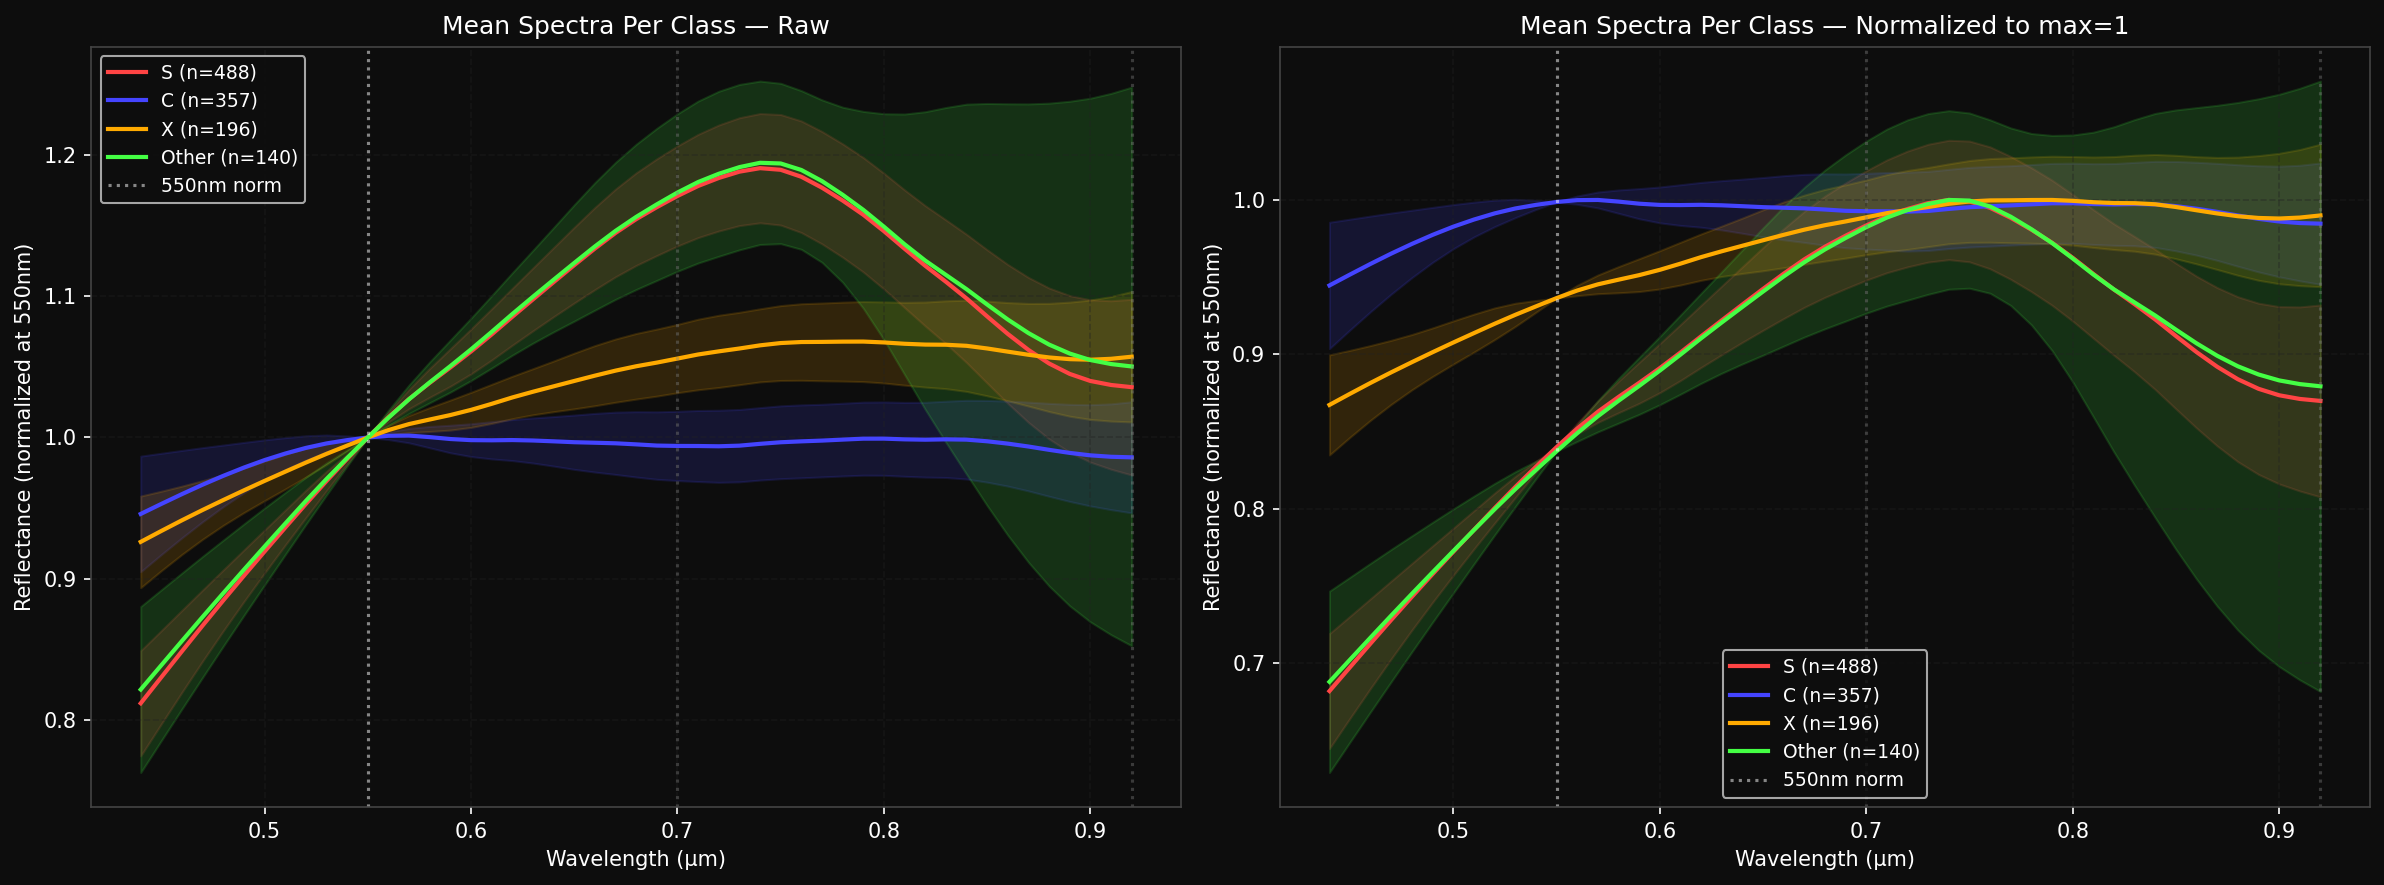

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

groups  = ['S', 'C', 'X', 'Other']
colors  = ['#ff4444', '#4444ff', '#ffaa00', '#44ff44']

# Mean spectrum per group
for ax, (normalize, title) in zip(axes, [
    (False, 'Mean Spectra Per Class — Raw'),
    (True,  'Mean Spectra Per Class — Normalized to max=1'),
]):
    for group, color in zip(groups, colors):
        mask   = matched_df['Main Group'] == group
        if mask.sum() == 0:
            continue
        spectra = spectra_matrix[mask]
        mean_s  = spectra.mean(axis=0)
        std_s   = spectra.std(axis=0)

        if normalize:
            mean_s = mean_s / mean_s.max()

        ax.plot(wavelengths, mean_s, color=color,
                label=f'{group} (n={mask.sum()})', linewidth=2)
        ax.fill_between(wavelengths,
                        mean_s - std_s, mean_s + std_s,
                        color=color, alpha=0.15)

    ax.axvline(0.55, color='white', linestyle=':', alpha=0.5, label='550nm norm')
    ax.axvline(0.70, color='gray',  linestyle=':', alpha=0.4)
    ax.axvline(0.92, color='gray',  linestyle=':', alpha=0.4)
    ax.set_xlabel('Wavelength (μm)')
    ax.set_ylabel('Reflectance (normalized at 550nm)')
    ax.set_title(title)
    ax.legend(fontsize=9)
    ax.grid(True)

plt.tight_layout()
# plt.savefig(os.path.join(plots_path, '01_mean_spectra_per_class.png'),
#             dpi=200, bbox_inches='tight')
plt.show()

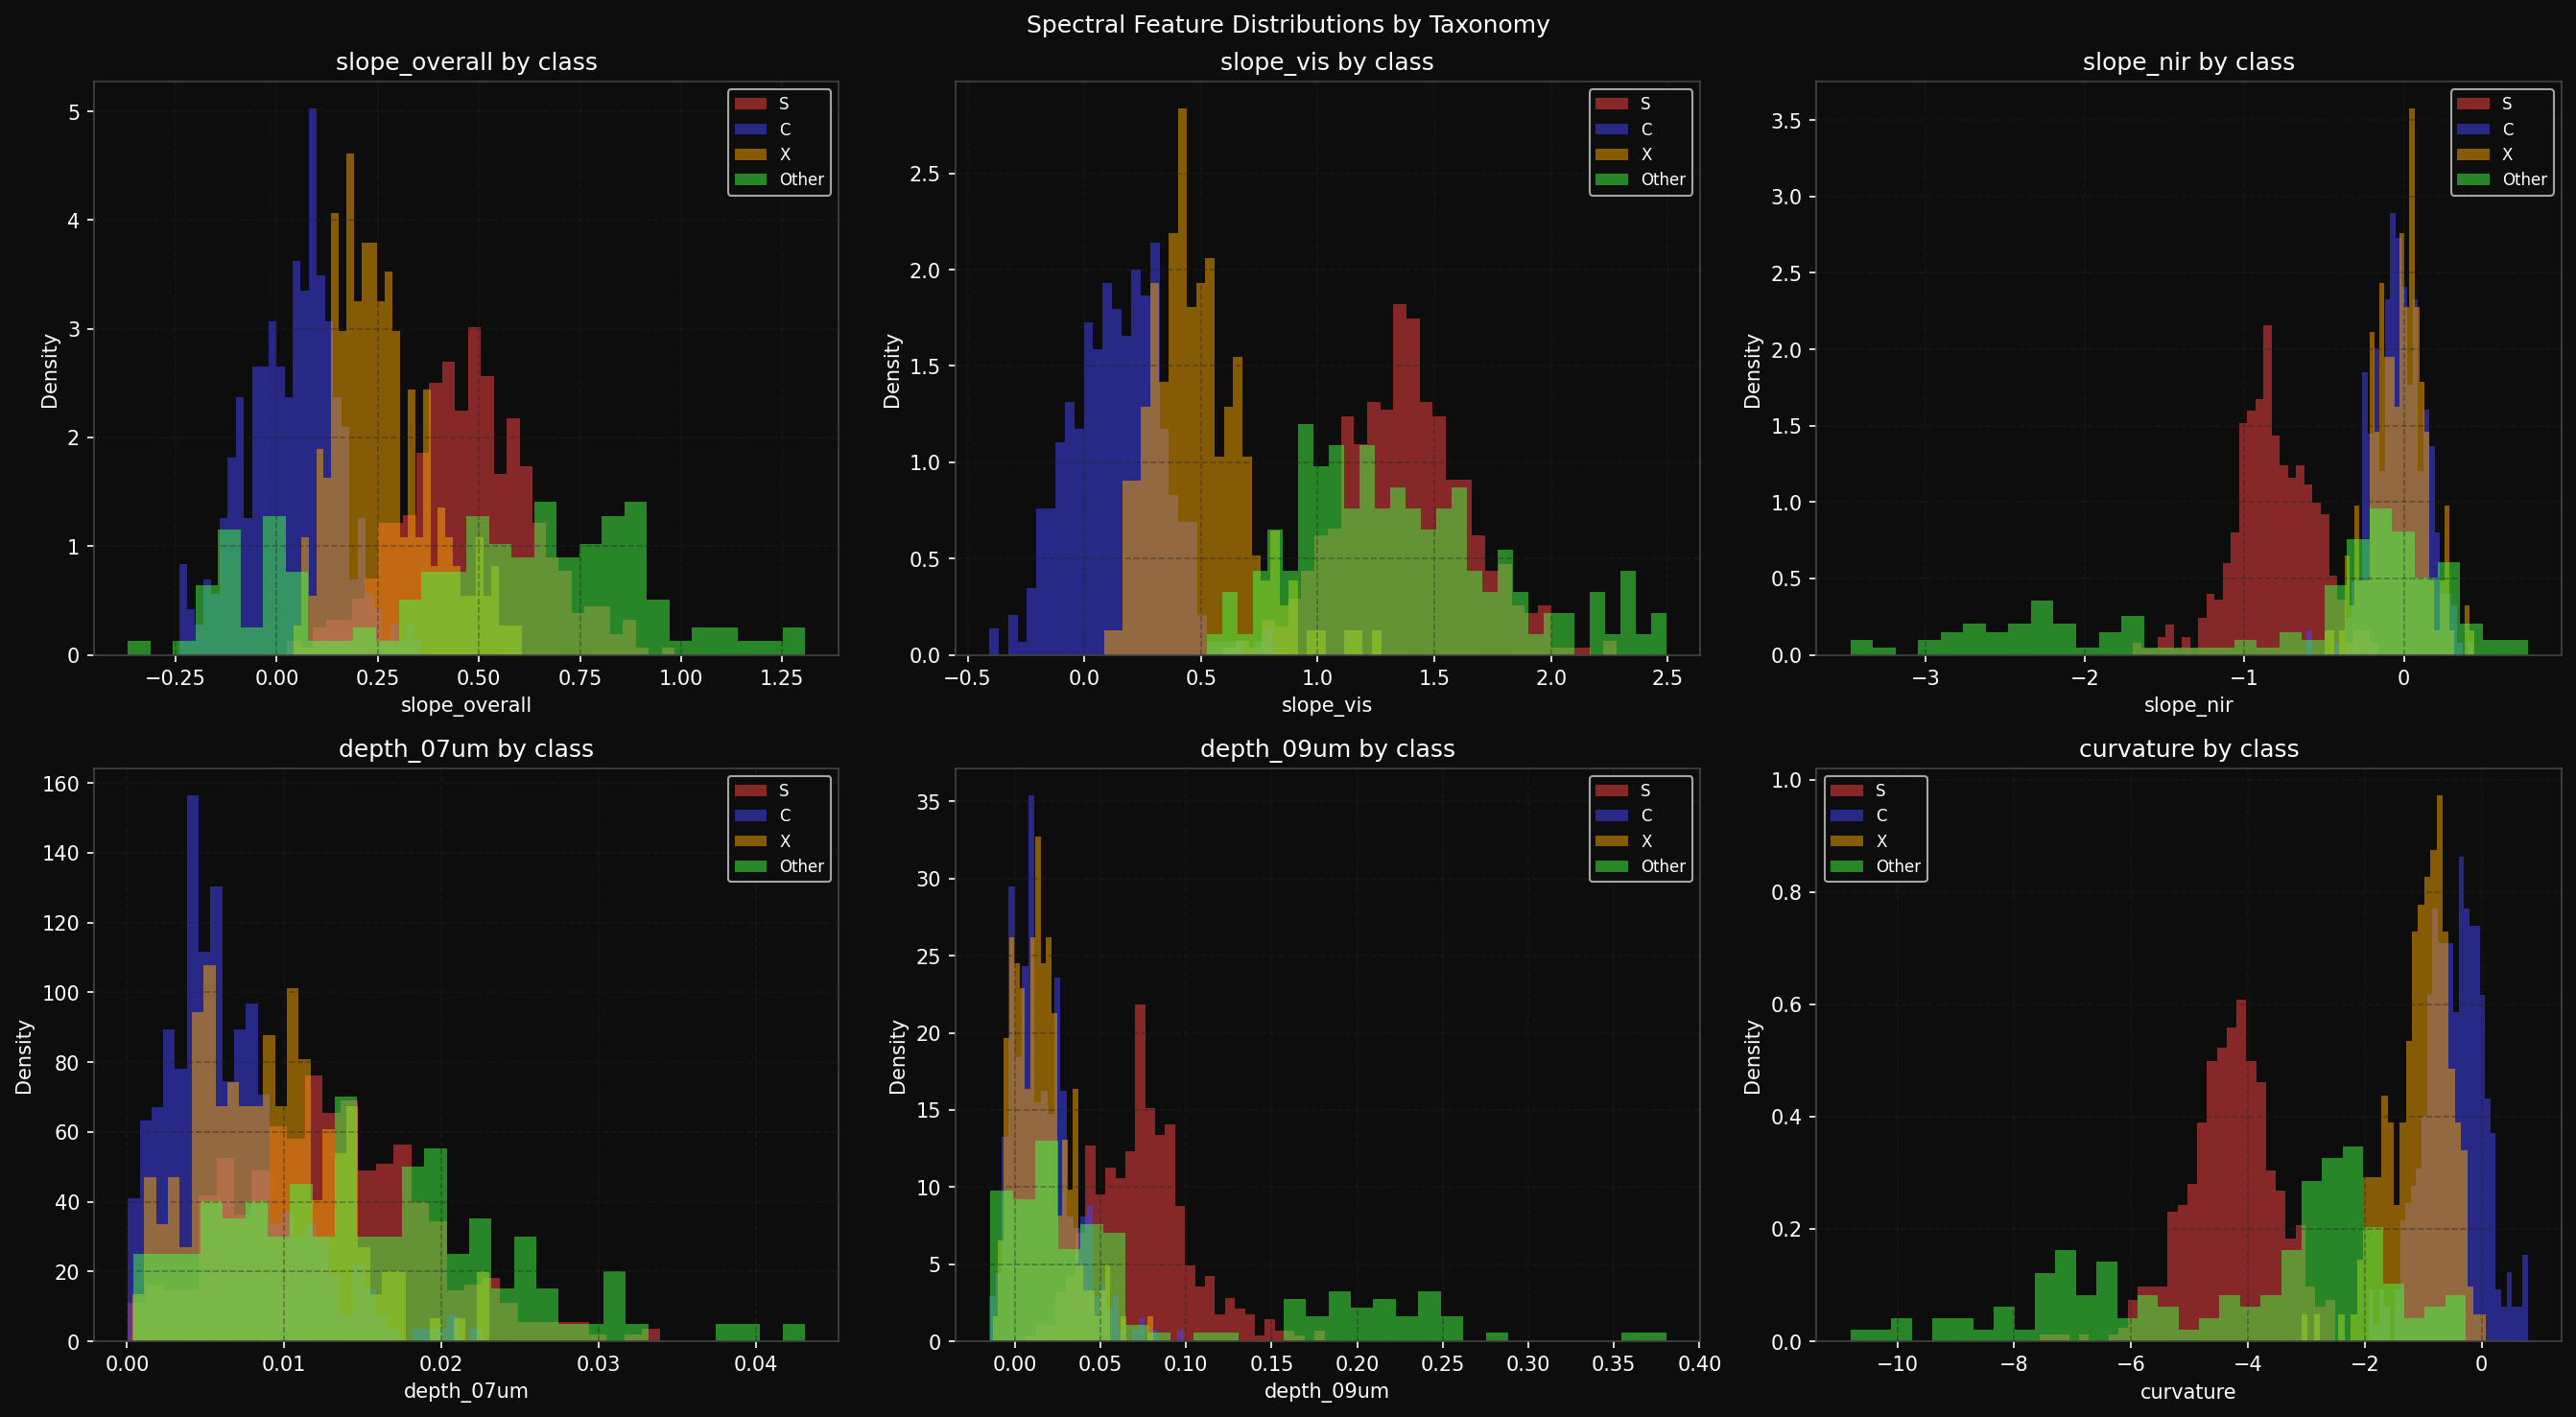

In [19]:
spec_features = ['slope_overall', 'slope_vis', 'slope_nir',
                 'depth_07um', 'depth_09um', 'curvature']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, feat in zip(axes.flatten(), spec_features):
    for group, color in zip(groups, colors):
        mask = matched_df['Main Group'] == group
        if mask.sum() == 0:
            continue
        ax.hist(matched_df.loc[mask, feat], bins=30,
                alpha=0.5, color=color,
                label=f'{group}', density=True, edgecolor='none')
    ax.set_xlabel(feat)
    ax.set_ylabel('Density')
    ax.set_title(f'{feat} by class')
    ax.legend(fontsize=8)
    ax.grid(True)

plt.suptitle('Spectral Feature Distributions by Taxonomy', fontsize=12)
plt.tight_layout()
# plt.savefig(os.path.join(plots_path, '01_spectral_feature_distributions.png'),
#             dpi=200, bbox_inches='tight')
plt.show()

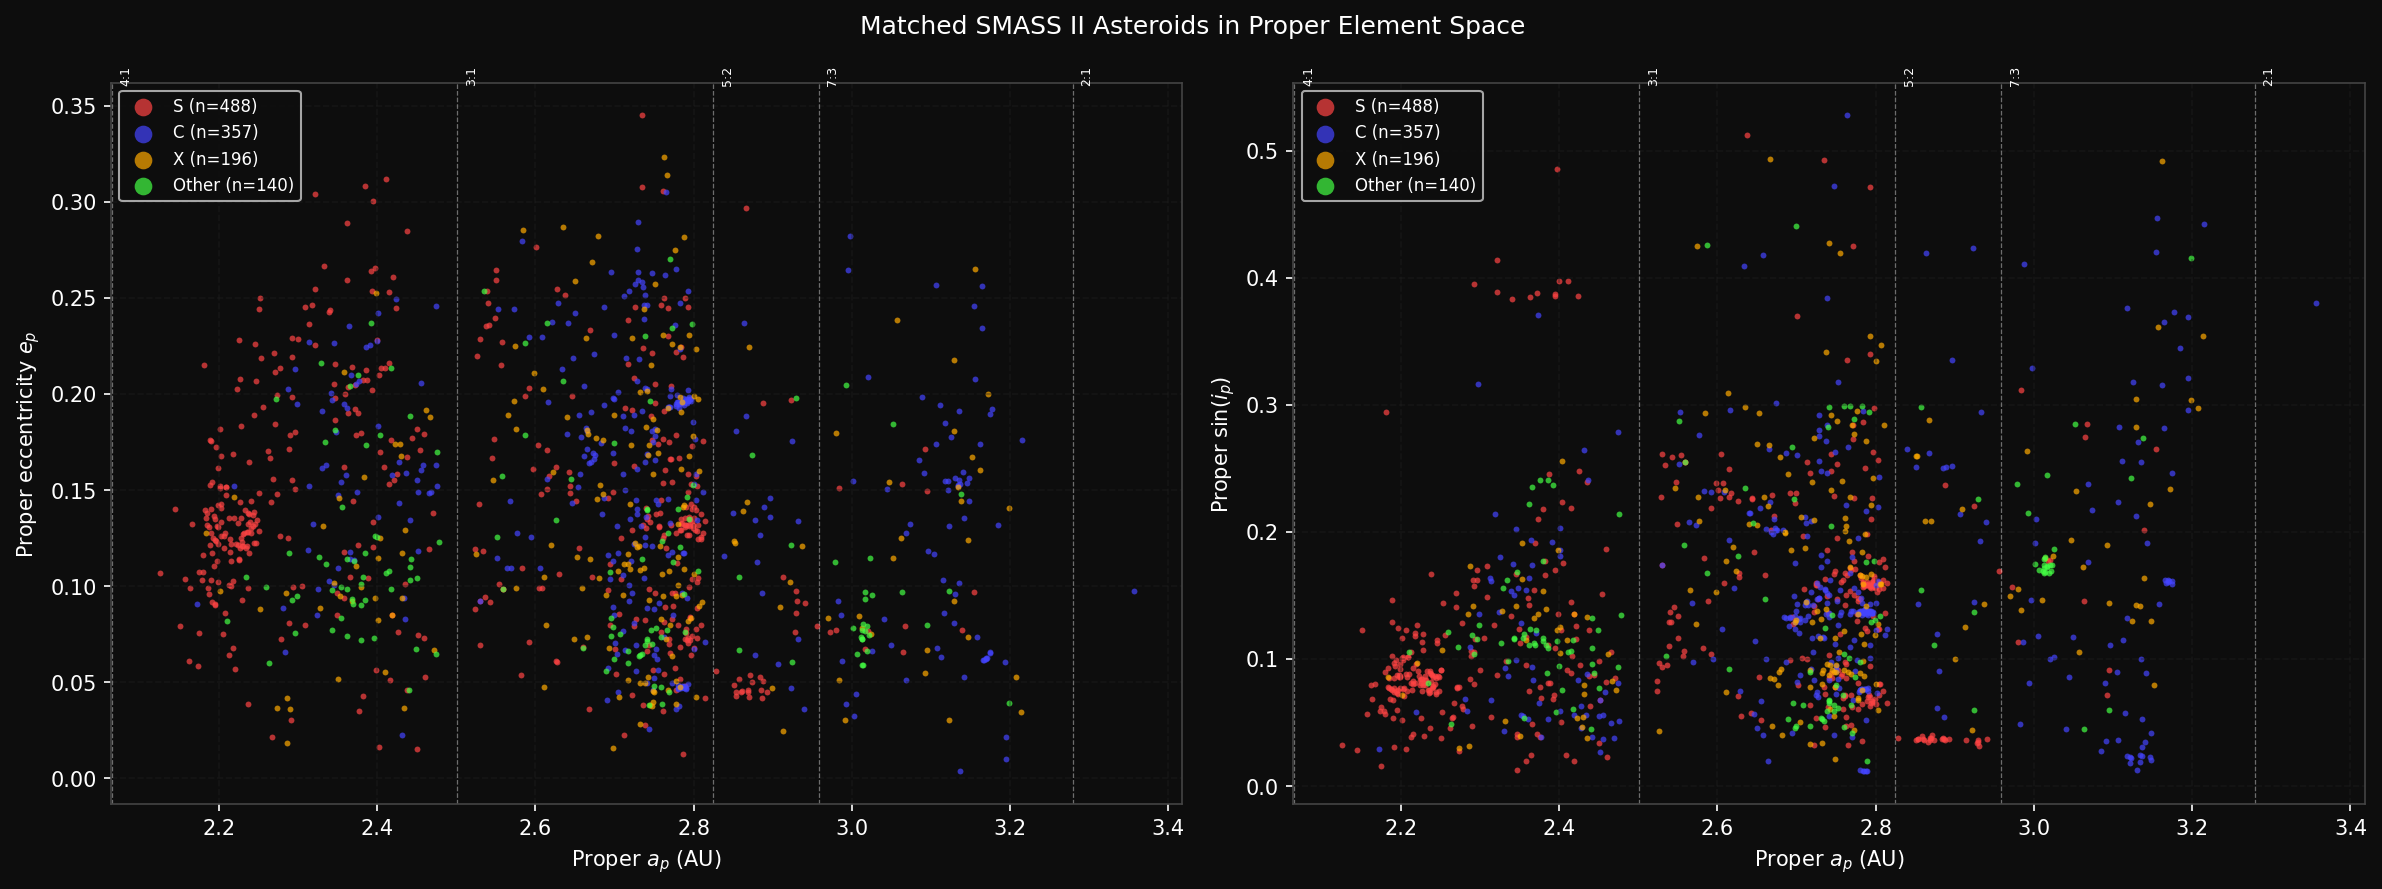

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

resonances = {'4:1': 2.065, '3:1': 2.501, '5:2': 2.825,
              '7:3': 2.958, '2:1': 3.279}

for ax, (ycol, ylabel) in zip(axes, [
    ('e_p',     'Proper eccentricity $e_p$'),
    ('sin_i_p', 'Proper $\\sin(i_p)$'),
]):
    for group, color in zip(groups, colors):
        mask = matched_df['Main Group'] == group
        if mask.sum() == 0:
            continue
        ax.scatter(matched_df.loc[mask, 'a_p'],
                   matched_df.loc[mask, ycol],
                   s=8, c=color, alpha=0.7,
                   label=f'{group} (n={mask.sum()})',
                   linewidths=0)

    for name, loc in resonances.items():
        ax.axvline(loc, color='white', linewidth=0.6,
                   linestyle='--', alpha=0.4)
        ax.text(loc + 0.01, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 0.5,
                name, color='white', fontsize=6, rotation=90)

    ax.set_xlabel('Proper $a_p$ (AU)')
    ax.set_ylabel(ylabel)
    ax.legend(fontsize=8, markerscale=3)
    ax.grid(True)

plt.suptitle('Matched SMASS II Asteroids in Proper Element Space', fontsize=12)
plt.tight_layout()
# plt.savefig(os.path.join(plots_path, '01_matched_orbital_distribution.png'), dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
# Drop SpectrumDF column — spectra stored separately in matrix
unified_df = matched_df.drop(columns=['SpectrumDF']).copy()

unified_df.to_pickle(os.path.join(results_path, 'unified_df.pkl'))

print(f"\nFinal shape  : {unified_df.shape}")
print(f"Columns      : {list(unified_df.columns)}")
print(f"\nClass counts :")
print(unified_df['Main Group'].value_counts())
print(f"\nFamily members : {unified_df['is_family_member'].sum():,}")
print(f"Background     : {(~unified_df['is_family_member']).sum():,}")

Unified dataset saved → data/results/unified_df.pkl

Final shape  : (1181, 38)
Columns      : ['Name', 'Bus Class', 'Main Group', 'Asteroid_id', 'H', 'a_p', 'e_p', 'sin_i_p', 'n', 'g', 's', 'LCE', 'My', 'rms_a', 'rms_e', 'rms_sin_i', 'rms_n', 'rms_g', 'rms_s', 'lam_fit_deg', 'status', 'family_1', 'dv_fam_1', 'family_2', 'dv_fam_2', 'rescod', 'is_family_member', 'slope_overall', 'slope_vis', 'slope_nir', 'depth_07um', 'depth_09um', 'curvature', 'ref_044', 'ref_070', 'ref_085', 'ref_092', 'ratio_nir_vis']

Class counts :
Main Group
S        488
C        357
X        196
Other    140
Name: count, dtype: int64

Family members : 275
Background     : 906


In [23]:
# How many families have enough SMASS II coverage
fam_matched = unified_df[unified_df['is_family_member']]

family_coverage = (
    fam_matched.groupby('family_1')
    .agg(
        n_members        = ('Asteroid_id', 'count'),
        dominant_type    = ('Main Group', lambda x: x.value_counts().index[0]),
        type_counts      = ('Main Group', lambda x: dict(x.value_counts())),
        purity           = ('Main Group', lambda x: x.value_counts().iloc[0] / len(x))
    )
    .sort_values('n_members', ascending=False)
    .reset_index()
)

print(f"Families with any SMASS II member  : {len(family_coverage)}")
print(f"Families with 3+ members           : {(family_coverage['n_members'] >= 3).sum()}")
print(f"Families with 5+ members           : {(family_coverage['n_members'] >= 5).sum()}")
print(f"Families with 10+ members          : {(family_coverage['n_members'] >= 10).sum()}")

print(f"\nTop 20 families by SMASS II coverage:")
print(family_coverage.head(20).to_string())

Families with any SMASS II member  : 42
Families with 3+ members           : 18
Families with 5+ members           : 17
Families with 10+ members          : 10

Top 20 families by SMASS II coverage:
    family_1  n_members dominant_type                            type_counts    purity
0         93         35             S                      {'S': 34, 'C': 1}  0.971429
1        668         28             C                              {'C': 28}  1.000000
2        158         22             S                              {'S': 22}  1.000000
3        847         22             S                  {'S': 15, 'Other': 7}  0.681818
4        221         21         Other  {'Other': 15, 'X': 3, 'S': 2, 'C': 1}  0.714286
5          4         19         Other                  {'Other': 13, 'S': 6}  0.684211
6         24         15             C                              {'C': 15}  1.000000
7         15         14             S              {'S': 11, 'X': 2, 'C': 1}  0.785714
8       1726      

In [ ]:
# Checking family 221 Bus Classes - As it contains 15 members within 'Other' class, which is interesting for the analysis
fam221 = unified_df[unified_df['family_1'] == 221]
print("Family 221 Bus Classes:")
print(fam221[['Name', 'Bus Class', 'Main Group']].to_string())

Family 221 Bus Classes:
                  Name Bus Class Main Group
170            221 Eos         K      Other
224       339 Dorothea         K      Other
271        423 Diotima         C          C
303      513 Centesima         K      Other
326        579 Sidonia         K      Other
346         633 Zelima         S          S
350       653 Berenike         K      Other
352        661 Cloelia         K      Other
378        742 Edisona         K      Other
477      1114 Lorraine        Xc          X
483        1148 Rarahu         K      Other
488       1186 Turnera        Sq          S
498         1234 Elyna         K      Other
563      1604 Tombaugh        Xc          X
601  1799 Koussevitzky         K      Other
613         1882 Rauma         K      Other
615  1903 Adzhimushkaj         K      Other
792        2957 Tatsuo         K      Other
800    3028 Zhangguoxi         K      Other
819     3214 Makarenko        Xc          X
896       3713 Pieters         K      Other


In [ ]:
# Checking family 4 for same reason
fam4 = unified_df[unified_df['family_1'] == 4]
print("Family 4 Bus Classes:")
print(fam4[['Name', 'Bus Class', 'Main Group']].to_string())

Family 4 Bus Classes:
                   Name Bus Class Main Group
2               4 Vesta         V      Other
54           63 Ausonia        Sa          S
318         556 Phyllis         S          S
630         2029 Binomi         S          S
634         2045 Peking         V      Other
707         2508 Alupka         V      Other
712          2547 Hubei         V      Other
810            3155 Lee         V      Other
826       3265 Fletcher         V      Other
842   3376 Armandhammer        Sq          S
857         3498 Belton         V      Other
904          3782 Celle         V      Other
966        4311 Zguridi         V      Other
1036      4900 Maymelou         V      Other
1048       4993 1983 GR         V      Other
1054         5051 Ralph        Sr          S
1063        5108 Lubeck         S          S
1064       5111 Jacliff         R      Other
1075        5240 Kwasan         V      Other


In [26]:
print("Bus Classes mapped to 'Other':")
print(
    unified_df[unified_df['Main Group'] == 'Other']
    ['Bus Class']
    .value_counts()
    .to_string()
)

Bus Classes mapped to 'Other':
Bus Class
V     35
L     32
K     31
Ld    12
T     10
A     10
D      5
R      4
O      1
